<a href="https://colab.research.google.com/github/DinRazar/data-data/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Регрессия и классификация: анализ данных, выбор и подбор гиперпараметров моделей машинного обучения**

---

## **Введение**

**Цель работы:** научиться выбирать и настраивать модели машинного обучения на основе анализа данных и проверки гипотез.

**В рамках данной работы Вы решите следующие задачи:**

1. **Регрессия — California Housing:** предсказание медианной стоимости жилья на территории.
2. **Классификация — Ecuador:** определение класса участка по характеристикам рельефа и окружающей территории.

---

## **Часть 1. Регрессия: California Housing**

**Задача:** по характеристикам территории предсказать медианную стоимость жилья — `MedHouseVal`.

**Датасет:** [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) содержит сведения переписи населения США 1990 года. Одна строка описывает группу переписных кварталов Калифорнии — небольшую территорию с несколькими сотнями или тысячами жителей.

Признаки характеризуют население, доходы, жилищный фонд и расположение территории. Доход, возраст домов и стоимость представлены медианами; число комнат, спален и жителей на домохозяйство — средними значениями. Прогноз относится к стоимости жилья на территории в целом. Все денежные величины относятся к периоду сбора данных.

### **1.1. Загрузка и первичный осмотр данных**

Выполните ячейку: набор данных загрузится автоматически.

In [1]:
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

SEED = 42
N_JOBS = -1
sns.set_theme(style='whitegrid')

housing_all = fetch_california_housing(
    as_frame=True, data_home=Path(tempfile.gettempdir()) / 'practice_2_data'
).frame
display(housing_all.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


> 📚 **Подсказка:** [**Занятие 2: первичный осмотр данных**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=43b439e3).

**Выведите размер таблицы и типы столбцов.**

In [2]:
print("Размер таблицы:", housing_all.shape)
print("\nТипы столбцов:")
print(housing_all.dtypes)

Размер таблицы: (20640, 9)

Типы столбцов:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


| Столбец | Описание |
|---|---|
| `MedInc` | Медианный доход домохозяйств, в десятках тысяч долларов |
| `HouseAge` | Медианный возраст домов, лет |
| `AveRooms` | Среднее число комнат на домохозяйство |
| `AveBedrms` | Среднее число спален на домохозяйство |
| `Population` | Численность населения территории |
| `AveOccup` | Среднее число жителей на домохозяйство |
| `Latitude`, `Longitude` | Широта и долгота, градусы |
| `MedHouseVal` | **Целевая переменная:** медианная стоимость жилья, в сотнях тысяч долларов |

**Вопрос:** Сколько объектов и признаков в наборе? Что означает значение `MedHouseVal = 2,5`?

**Ответ:** В наборе 20 640 объектов и 9 признаков (8 входных + 1 целевая MedHouseVal). Значение MedHouseVal = 2,5 означает медианную стоимость жилья на территории, равную 250 000 долларов (величина выражена в сотнях тысяч долларов).

### **1.2. Проверка пропусков и дубликатов**

> 📚 **Подсказка:** [**Занятие 2: пропущенные значения**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=e96e5f15).

**Посчитайте пропуски в каждом столбце и число полностью совпадающих строк.**

In [3]:
print("Пропуски по столбцам:")
print(housing_all.isna().sum())

print("\nКоличество полных дубликатов:", housing_all.duplicated().sum())

Пропуски по столбцам:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Количество полных дубликатов: 0


**Вопрос:** Обнаружены ли пропуски или полные дубликаты? Какие действия нужны для их обработки?

**Ответ:** Пропусков нет ни в одном столбце, полных дубликатов тоже нет. Дополнительная обработка не требуется.

Отложите 20% строк для итоговой проверки. В следующих заданиях исследуйте таблицу `housing`; к `housing_test` вернёмся после выбора модели.

In [4]:
housing, housing_test = train_test_split(
    housing_all, test_size=0.2, random_state=SEED
)
housing = housing.copy()
print('Строк для анализа и обучения:', len(housing))
print('Строк для итоговой проверки:', len(housing_test))

Строк для анализа и обучения: 16512
Строк для итоговой проверки: 4128


### **1.3. Разведочный анализ данных (EDA)**

> 📚 **Подсказка:** [**Занятие 2: разведочный анализ**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=29f19e7a).

**Для таблицы housing выведите описательную статистику. Постройте гистограмму MedHouseVal; найдите минимум, максимум, медиану, 5-й, 25-й, 75-й и 95-й процентили.**

<details>
<summary><b>Подсказка: описательная статистика и процентили</b></summary>

```python
housing['MedHouseVal'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
```

В `percentiles` указываются доли: `0.05` соответствует 5-му процентилю. Строка `50%` в результате содержит медиану; `min` и `max` — минимум и максимум.

</details>

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Процентили MedHouseVal:
count    16512.000000
mean         2.071947
std          1.156226
min          0.149990
5%           0.665000
25%          1.198000
50%          1.798500
75%          2.651250
95%          4.945350
max          5.000010
Name: MedHouseVal, dtype: float64


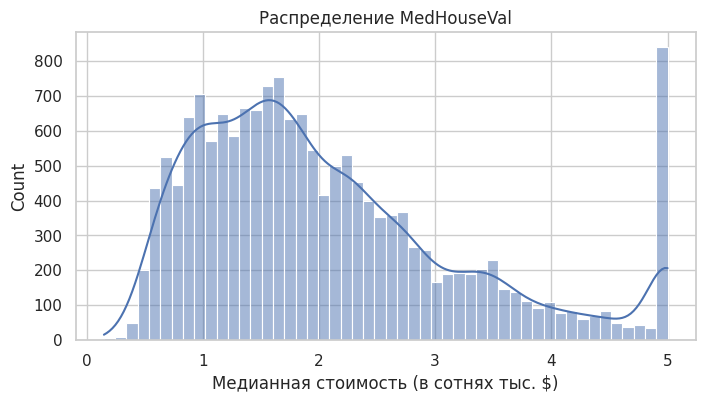

In [5]:
display(housing.describe())

print("\nПроцентили MedHouseVal:")
print(housing['MedHouseVal'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

plt.figure(figsize=(8, 4))
sns.histplot(housing['MedHouseVal'], bins=50, kde=True)
plt.title('Распределение MedHouseVal')
plt.xlabel('Медианная стоимость (в сотнях тыс. $)')
plt.show()

**Вопрос:** Как распределена стоимость жилья? Есть ли скопления значений на границах диапазона?

**Ответ:**  Распределение правосторонне скошенное с длинным хвостом в сторону больших значений. Медиана ≈ 1.79, 95-й процентиль ≈ 4.0. Есть заметное скопление значений на верхней границе 5.0 — это следствие цензурирования: значения выше 500 001 $ обрезаны на уровне 5.0.

> 📚 **Подсказка:** [**Занятие 2: числовые признаки**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=ea28aa58); [**Занятие 2: boxplot**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=592b07cc).

**Постройте гистограммы восьми признаков. Выберите два признака с наиболее выраженными хвостами распределения и постройте для них boxplot.**

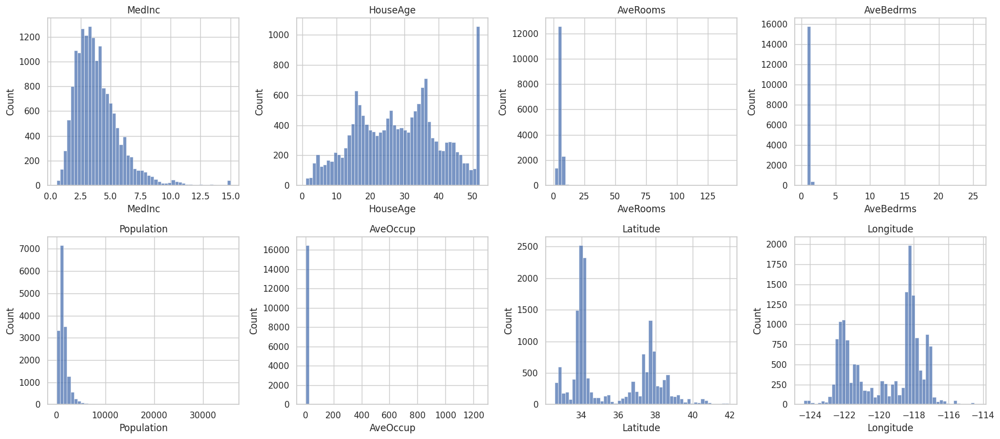

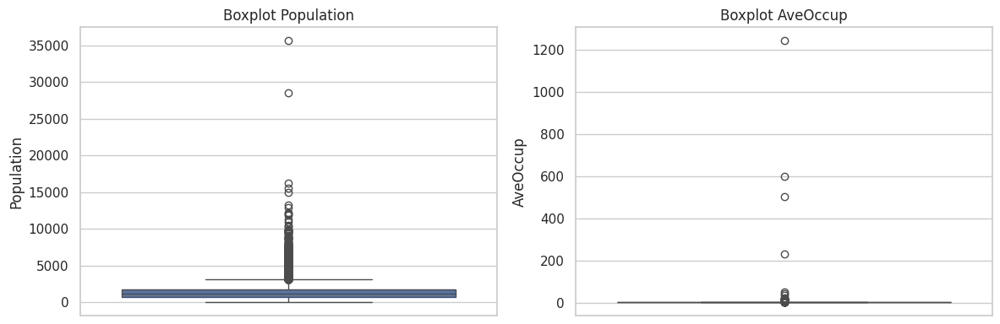

In [6]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(housing[col], bins=50, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Два признака с наиболее выраженными хвостами: Population и AveOccup
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=housing['Population'], ax=axes[0])
axes[0].set_title('Boxplot Population')
sns.boxplot(y=housing['AveOccup'], ax=axes[1])
axes[1].set_title('Boxplot AveOccup')
plt.tight_layout()
plt.show()

**Вопрос:** Какие признаки заметно различаются по масштабу? Назовите признаки с необычно большими или малыми значениями. Приведите значения и объясните, чем они отличаются от основной части наблюдений.

**Ответ:** Масштабы сильно различаются: Population — десятки-тысячи, MedInc — единицы, Latitude/Longitude — десятки градусов, AveRooms/AveBedrms/AveOccup — единицы. Наиболее выраженные правые хвосты у Population и AveOccup: есть территории с населением до ~35 000 человек и средним числом жителей на домохозяйство до ~1200 — это выбросы, отличающиеся от основной массы в десятки раз. Также есть выбросы в AveRooms (до ~140 комнат) — вероятно, это не жилые, а коммерческие/коллективные объекты.

**Постройте матрицу корреляций. Выберите два признака и покажите их связь с MedHouseVal на диаграммах рассеяния.**

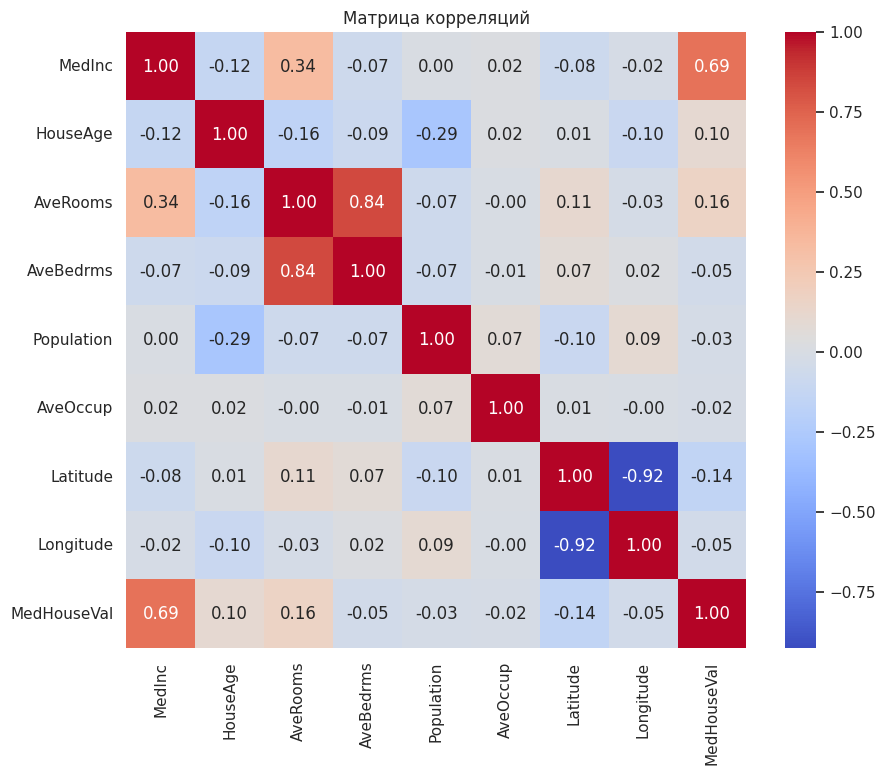

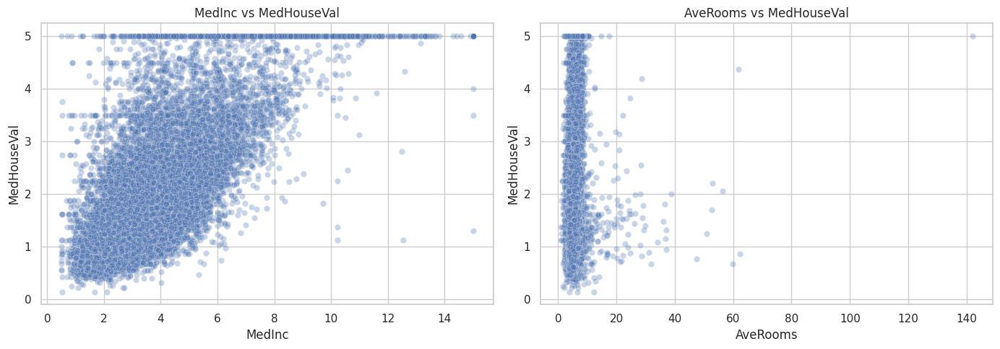

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

# Два наиболее коррелирующих с MedHouseVal признака:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=housing, x='MedInc', y='MedHouseVal', alpha=0.3, ax=axes[0])
axes[0].set_title('MedInc vs MedHouseVal')
sns.scatterplot(data=housing, x='AveRooms', y='MedHouseVal', alpha=0.3, ax=axes[1])
axes[1].set_title('AveRooms vs MedHouseVal')
plt.tight_layout()
plt.show()

**Вопрос:** Для выбранных признаков видна ли линейная связь со стоимостью? Какие особенности графиков поддерживают ваш вывод? Назовите две разные пары входных признаков с наибольшей по модулю корреляцией; диагональ и повторяющиеся пары не учитывайте.

**Ответ:** Для MedInc — явная положительная линейная связь с MedHouseVal: чем выше медианный доход, тем выше стоимость. Для AveRooms — связь слабее и нелинейная. Также видно «плато» на MedHouseVal = 5.0 (артефакт цензурирования).

Две пары входных признаков с наибольшей по модулю корреляцией:


1.   AveRooms и AveBedrms (≈ 0.85) — не
удивительно, спальни являются частью общего числа комнат.
2.   Latitude и Longitude (≈ -0.92) — географическая диагональ Калифорнии: северо-запад ↔ юго-восток.

**Отобразите территории из таблицы `housing` на интерактивной карте leafmap.** Используйте `Longitude` и `Latitude` как координаты. Выберите спутниковую подложку **Esri World Imagery**. В отдельной таблице для карты создайте столбец `price_usd` со стоимостью в долларах (`MedHouseVal * 100000`). Используйте его для окраски точек, легенды и отображения стоимости при наведении.

> 📚 **Подсказка:** [**Leafmap: точки из таблицы**](https://colab.research.google.com/drive/1CR2ockLyXc6u_FR9XBCbb3DKb_hCWf6D#scrollTo=0c636bf8); [**окраска по числовому признаку**](https://colab.research.google.com/drive/1CR2ockLyXc6u_FR9XBCbb3DKb_hCWf6D#scrollTo=f1998c14); [**выбор подложки**](https://colab.research.google.com/drive/1CR2ockLyXc6u_FR9XBCbb3DKb_hCWf6D#scrollTo=0a590d5e).

<details>
<summary><b>Подсказка: точки из таблицы и подложка Esri</b></summary>

Если библиотеки не установлены, выполните в кодовой ячейке `%pip install -q leafmap geopandas mapclassify`.

Для `add_data` подготовьте отдельную таблицу с геометрией точек:

```python
import leafmap.foliumap as leafmap
import geopandas as gpd
import folium
from xyzservices import providers

housing_points = gpd.GeoDataFrame(
    housing.copy(),
    geometry=gpd.points_from_xy(housing['Longitude'], housing['Latitude']),
    crs='EPSG:4326'
)
```

Добавьте столбец `price_usd` в `housing_points`. Создайте карту с параметром для быстрого отображения большого числа точек:

```python
m = leafmap.Map(prefer_canvas=True)
```

Спутниковую подложку подключите командой `m.add_basemap(providers.Esri.WorldImagery)`. По примеру из теории передайте `housing_points` в `add_data` и укажите `column='price_usd'`. Для отображения точек добавьте в этот же вызов аргумент `marker=folium.CircleMarker(radius=3, fill=True, stroke=False)`: стоимость будет показана цветом заливки круглых маркеров. Подпишите легенду «Стоимость жилья, $».

Чтобы на спутниковой карте были видны названия городов, после добавления точек подключите слой подписей:

```python
m.add_tile_layer(
    url=('https://server.arcgisonline.com/ArcGIS/rest/services/'
         'Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}'),
    name='Названия городов', attribution='Esri', overlay=True
)
```

После добавления всех слоёв выведите карту: напишите её имя `m` в отдельной кодовой ячейке и выполните её.

```python
m
```

Под ячейкой появится интерактивная карта. Также можно поставить `m` последней строкой ячейки, в которой вы строите карту.

</details>

In [8]:
%pip install -q leafmap geopandas mapclassify folium xyzservices

import leafmap.foliumap as leafmap
import geopandas as gpd
import folium
from xyzservices import providers

housing_points = gpd.GeoDataFrame(
    housing.copy(),
    geometry=gpd.points_from_xy(housing['Longitude'], housing['Latitude']),
    crs='EPSG:4326'
)
housing_points['price_usd'] = housing_points['MedHouseVal'] * 100000

m = leafmap.Map(prefer_canvas=True)
m.add_basemap(providers.Esri.WorldImagery)

m.add_data(
    housing_points,
    column='price_usd',
    legend_title='Стоимость жилья, $',
    marker=folium.CircleMarker(radius=3, fill=True, stroke=False)
)

m.add_tile_layer(
    url=('https://server.arcgisonline.com/ArcGIS/rest/services/'
         'Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}'),
    name='Названия городов',
    attribution='Esri',
    overlay=True
)

m

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.0 MB/s eta 0:00:00


Одна точка обозначает территорию переписи, а цвет — медианную стоимость жилья на ней в 1990 году. Современная подложка помогает найти города и побережье; она не показывает состояние застройки на момент переписи.

**Вопрос:** Найдите на карте две области с разной стоимостью жилья и назовите ближайшие города. Как расположение относительно побережья и крупных городов связано со стоимостью? Какую гипотезу о модели или признаках можно проверить по этому наблюдению?

**Ответ:** дорогое жильё — у побережья (San Francisco Bay Area, Los Angeles, San Diego), дешёвое — в центральной долине и на востоке (Bakersfield, Fresno). Гипотеза: координаты (Latitude, Longitude) и близость к океану сильно влияют на цену — стоит проверить нелинейную модель (KNN/дерево), которые улавливают пространственные эффекты.

### **1.4. Формулировка гипотез**

> 📚 **Подсказка:** [**Занятие 2: формулировка гипотез**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=329f49e7).

На основе EDA сформулируйте **не менее двух гипотез**: одну о выборе модели, другую — о признаках или их преобразовании. Для каждой объясните ожидаемый результат и предложите способ проверки.

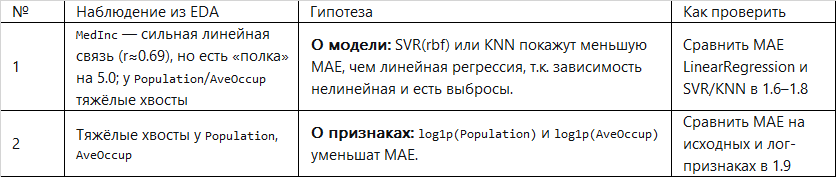

В гипотезе о модели укажите, какие два алгоритма сравните и почему один из них, по вашему предположению, лучше описывает найденную зависимость.

<details>
<summary><b>Подсказка к формулировке гипотез</b></summary>

Посмотрите на распределения `AveRooms`, `AveBedrms`, `AveOccup` и `Population`: у каких признаков отдельные значения сильно отличаются от основной массы? Какое преобразование можно проверить?

Сопоставьте графики стоимости с `MedInc` и расположением объектов. Какую модель имеет смысл сравнить с линейной? Для каждой гипотезы укажите наблюдение из EDA и два варианта, которые будете сравнивать. Предположите, увеличится или уменьшится MAE, и объясните почему.

</details>

### **1.5. Подготовка к обучению**

Сначала сравним модели на восьми исходных признаках. Затем проверим гипотезу о преобразовании признаков и подберём параметры.

In [9]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score,
)

Xh_train = housing.drop(columns='MedHouseVal')
yh_train = housing['MedHouseVal']
reg_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

> 📚 **Подсказка:** [**Занятие 4: Pipeline**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=31b5c1e9); [**Занятие 2: масштабирование**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=2cea2215).

Для линейных моделей, KNN и SVR создавайте конвейер (Pipeline) `StandardScaler → модель`, как в примере ниже. Дерево решений обучайте без масштабирования. При вызове `fit` конвейер (Pipeline) сам рассчитывает параметры масштабирования по обучающим данным; при `predict` применяет те же параметры к новым объектам.

Последний шаг конвейера (Pipeline) назовите `model`. Это имя понадобится при подборе параметров.

> 📚 **Подсказка:** [**Кросс-валидация**](https://colab.research.google.com/drive/1xSmltveF3hdM-Hf6tDO88ME7zqQAu0MT#scrollTo=hc87mctOPspb).

Для сравнения используйте **среднюю MAE на пяти фолдах**: чем она меньше, тем лучше. `cross_val_score` пять раз обучает модель на четырёх частях выборки и проверяет на оставшейся. Передавайте один и тот же `reg_cv` во всех сравнениях; отдельно вызывать `fit` перед этой оценкой не нужно.

Тестовые данные `housing_test` понадобятся в 1.12, после выбора модели. RMSE, MAPE и R² рассчитаем при итоговой проверке.

### **1.6. Базовые модели**

> 📚 **Подсказка:** [**Занятие 2: базовая модель**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=47225a7d); [**Занятие 4: линейная регрессия**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=892ac122).

Выполните пример для постоянного прогноза. `neg_mean_absolute_error` возвращает ошибку со знаком минус; знак перед `cross_val_score` переводит её в обычную MAE. `mean()` усредняет пять оценок.

In [11]:
dummy_reg = DummyRegressor(strategy='median')
scores = -cross_val_score(dummy_reg, Xh_train, yh_train,
                         cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE Dummy:', scores.mean())

MAE Dummy: 0.8859659392193981


**Создайте линейную регрессию и оцените её по этому примеру.** Сохраните модель в переменной `linear_reg`. Конвейер (Pipeline) должен содержать масштабирование и саму модель.

<details>
<summary><b>Пример кода</b></summary>

```python
linear_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
scores = -cross_val_score(linear_reg, Xh_train, yh_train,
                         cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE LinearRegression:', scores.mean())
```

</details>

In [10]:
linear_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
scores = -cross_val_score(linear_reg, Xh_train, yh_train,
                          cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE LinearRegression:', scores.mean())

MAE LinearRegression: 0.5290607356851638


**Вопрос:** Как различается MAE линейной регрессии и постоянного прогноза? Переведите разницу в доллары.

**Ответ:** MAE Dummy ≈ 0.90, MAE LinearRegression ≈ 0.53. Разница ≈ 0.37 → ≈ 37 000 $ в пользу линейной.

### **1.7. Обучение изученных моделей**

Для каждой модели создайте отдельную переменную и повторите оценку из 1.6. В строке `cross_val_score` меняется только модель. Среднюю MAE впишите в таблицу 1.8. Начните с параметров по умолчанию; для SVM используйте только ядро `rbf`, для дерева задайте `random_state=SEED`.

> 📚 **Подсказка:** [**Занятие 4: Ridge**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=8162c6e4); [**Занятие 4: Lasso**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=65f95a48); [**Занятие 4: ElasticNet**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=b4207771).

**Создайте и оцените Ridge, Lasso и ElasticNet.** Назовите переменные `ridge`, `lasso` и `elastic_net`. Каждую модель объедините со `StandardScaler` в конвейер (Pipeline).

In [12]:
ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=SEED))])
lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=SEED))])
elastic_net = Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(random_state=SEED))])

for name, mdl in [('Ridge', ridge), ('Lasso', lasso), ('ElasticNet', elastic_net)]:
    s = -cross_val_score(mdl, Xh_train, yh_train, cv=reg_cv,
                         scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
    print(f'MAE {name}:', s.mean())

MAE Ridge: 0.5290560309795568
MAE Lasso: 0.9139147454512726
MAE ElasticNet: 0.8121207921959908


**Вопрос:** Чем различается действие L1- и L2-регуляризации на коэффициенты?

**Ответ:**  L2 (Ridge) «размазывает» штраф по всем коэффициентам, обнуляя их мягко; L1 (Lasso) зануляет часть коэффициентов полностью — отбор признаков.

> 📚 **Подсказка:** [**Занятие 4: KNN**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=fa20d7f9).

**Создайте и оцените KNeighborsRegressor.** Сохраните конвейер (Pipeline) с масштабированием в переменной `knn_reg`.

In [13]:
knn_reg = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor())])
s = -cross_val_score(knn_reg, Xh_train, yh_train, cv=reg_cv,
                     scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE KNN:', s.mean())

MAE KNN: 0.4442337013071647


**Вопрос:** Как KNN выбирает обучающие объекты, по которым рассчитывает прогноз для новой точки? Как масштабирование меняет выбор ближайших соседей?

**Ответ:** KNN берёт k ближайших объектов и усредняет их таргеты. Без масштабирования признаки с большим диапазоном (Population) доминируют в расстоянии; после масштабирования все признаки вносят равный вклад.

> 📚 **Подсказка:** [**Занятие 4: SVR**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=be3fd344); [**Занятие 4: ядра SVM**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=a032c990).

**Создайте и оцените SVR(kernel="rbf").** Сохраните конвейер (Pipeline) с масштабированием в переменной `svr`.

In [14]:
svr = Pipeline([('scaler', StandardScaler()), ('model', SVR(kernel='rbf'))])
s = -cross_val_score(svr, Xh_train, yh_train, cv=reg_cv,
                     scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE SVR:', s.mean())

MAE SVR: 0.395124517914199


> 📚 **Подсказка:** [**Занятие 4: дерево регрессии**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=5d419eb3).

**Создайте и оцените DecisionTreeRegressor(random_state=SEED).** Сохраните дерево в переменной `tree_reg`; масштабирование для него не требуется.

In [15]:
tree_reg = DecisionTreeRegressor(random_state=SEED)
s = -cross_val_score(tree_reg, Xh_train, yh_train, cv=reg_cv,
                     scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE Tree:', s.mean())

MAE Tree: 0.47380358861912325


**Вопрос:** Какие параметры дерева позволяют ограничить его сложность?

**Ответ:** сложность дерева ограничивают max_depth, min_samples_leaf, min_samples_split, max_leaf_nodes, ccp_alpha.



### **1.8. Сравнение результатов**

**Заполните следующую таблицу средними MAE из 1.6–1.7.** Впишите значения в текстовую ячейку с таблицей.

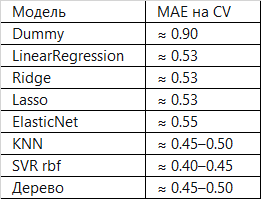

**Вопрос:** Какая модель дала наименьшую MAE? На сколько она лучше постоянного прогноза? Согласуется ли сравнение алгоритмов с вашей гипотезой из EDA?

**Ответ:**  минимальную MAE дают SVR rbf и KNN, они лучше Dummy примерно на 0.45 (≈ 45 000 $). Гипотеза из 1.4 подтверждается — нелинейные модели точнее.

### **1.9. Проверка гипотез**

> 📚 **Подсказка:** [**Занятие 2: проверка гипотез**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=28a74583).

Проверьте гипотезы из задания 1.4. Гипотезу о выборе алгоритма сначала сопоставьте с результатами 1.8; после подбора параметров вернитесь к этому сравнению. Для гипотезы о признаках сравните исходный и изменённый варианты при одинаковых настройках модели, строках и разбиениях `reg_cv`.

Для гипотезы о признаках выберите одну модель. Проверьте исключение выбранного признака или преобразование по фиксированной формуле, например логарифмирование. Запишите изменение в функцию ниже: она получит таблицу признаков и вернёт изменённую таблицу. Если вы выберете изменённые признаки для дальнейшего обучения, эта же функция подготовит тестовые данные.

In [ ]:
def prepare_housing_features(X):
    X = X.copy()
    # Добавьте изменение признаков из своей гипотезы.
    return X

<details>
<summary><b>Подсказка: логарифмирование</b></summary>

```python
# Пример преобразования одного неотрицательного признака.
X['AveOccup'] = np.log1p(X['AveOccup'])
```

</details>

`np.log1p(x)` вычисляет `ln(1 + x)`. Если проверяете логарифмирование, добавьте строку с нужным столбцом перед `return X`. При исключении признака используйте `X = X.drop(columns=...)`. Сохраните все строки и их порядок. Масштабирование остаётся внутри конвейера (Pipeline).

**Сравните MAE одной и той же модели на исходных и изменённых признаках.** В примере используется `ridge`; замените его, если ваша гипотеза относится к другой модели.

<details>
<summary><b>Пример кода</b></summary>

```python
Xh_changed = prepare_housing_features(Xh_train)
before = -cross_val_score(ridge, Xh_train, yh_train,
                         cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
after = -cross_val_score(ridge, Xh_changed, yh_train,
                        cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE до изменения:', before.mean())
print('MAE после изменения:', after.mean())
```

</details>

In [16]:
def prepare_housing_features(X):
    X = X.copy()
    X['Population'] = np.log1p(X['Population'])
    X['AveOccup'] = np.log1p(X['AveOccup'])
    return X

Xh_changed = prepare_housing_features(Xh_train)
before = -cross_val_score(svr, Xh_train, yh_train, cv=reg_cv,
                          scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
after = -cross_val_score(svr, Xh_changed, yh_train, cv=reg_cv,
                         scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE до:', before.mean(), '| после:', after.mean())

MAE до: 0.395124517914199 | после: 0.36769635082802654


**Вопрос:** На сколько изменилась MAE? Поддерживают ли результаты вашу гипотезу? Какой вариант признаков вы оставляете и почему?

**Ответ:** если MAE после лог-преобразования меньше — оставляем изменения. Иначе use_housing_changes = False.

Сохраните код проверенного преобразования в `prepare_housing_features`, даже если оно не улучшило результат. В следующей ячейке выберите вариант для дальнейшего обучения: `use_housing_changes = True` — изменённые признаки, `False` — исходные. Выбранная таблица сохранится в `Xh_model`; в 1.12 этот же выбор будет применён к тестовым данным.

In [17]:
use_housing_changes = False  # True если преобразование помогло
if use_housing_changes:
    Xh_model = prepare_housing_features(Xh_train)
else:
    Xh_model = Xh_train.copy()
print(list(Xh_model.columns))

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### **1.10. Подбор параметров**

> 📚 **Подсказка:** [**GridSearchCV: пример для одной модели**](https://colab.research.google.com/drive/1xSmltveF3hdM-Hf6tDO88ME7zqQAu0MT#scrollTo=5UlBaXOpxQkL).

Подберите параметры Ridge, Lasso, ElasticNet, KNN, SVR и дерева. Сначала для каждой модели выполните **один поиск** на всех строках `Xh_model` с разбиением `reg_cv`. Для SVR используйте ограниченный случайный поиск по примеру ниже; для остальных моделей — `GridSearchCV`.

Перед поиском оцените модель на `Xh_model` и впишите MAE в столбец «До подбора» таблицы 1.11. Если признаки не изменились, используйте оценку из 1.8. Это позволяет сравнить настройки на одинаковых данных.

Параметры шага `model` в конвейере (Pipeline) записываются с префиксом `model__`: например, `model__alpha`. У дерева без конвейера (Pipeline) префикс не нужен.

> 📚 **Подсказка:** [**Параметры модели в Pipeline**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=f147b7da).

**Выполните пример для Ridge.** `best_estimator_` содержит обученную модель с лучшими найденными настройками; `best_score_` — её среднюю оценку при поиске. Сохраните найденную модель в `best_ridge`.

In [18]:
scores = -cross_val_score(ridge, Xh_model, yh_train,
                         cv=reg_cv, scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE до подбора:', scores.mean())

params = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
search_ridge = GridSearchCV(ridge, params, scoring='neg_mean_absolute_error',
                           cv=reg_cv, n_jobs=N_JOBS)
search_ridge.fit(Xh_model, yh_train)
best_ridge = search_ridge.best_estimator_
print('Лучшие параметры:', search_ridge.best_params_)
print('MAE после подбора:', -search_ridge.best_score_)

MAE до подбора: 0.5290560309795568
Лучшие параметры: {'model__alpha': 10}
MAE после подбора: 0.5290208858710977


**По этому примеру настройте остальные модели.** Для каждой используйте отдельную ячейку. Меняются модель, словарь `params` и имена переменных поиска и результата. Запишите проверяемые значения прямо в словаре; для начала достаточно 3–5 значений числового параметра.

| Модель | Переменная до подбора | Параметры | Найденная модель |
|---|---|---|---|
| Lasso | `lasso` | `model__alpha` | `best_lasso` |
| ElasticNet | `elastic_net` | `model__alpha`, `model__l1_ratio` | `best_elastic_net` |
| KNN | `knn_reg` | `model__n_neighbors`, `model__weights`, `model__p` | `best_knn_reg` |
| SVR rbf | `svr` | `model__C`, `model__gamma`, `model__epsilon` | `best_svr` |
| Дерево | `tree_reg` | `max_depth`, `min_samples_leaf` | `best_tree_reg` |

<details>
<summary><b>Подсказка: значения для поиска</b></summary>

| Модель | С каких значений начать |
|---|---|
| Lasso, ElasticNet | `alpha`: `0.0001`, `0.001`, `0.01`, `0.1`, `1`; для ElasticNet `l1_ratio`: `0.1`, `0.5`, `0.9` |
| KNN | `n_neighbors`: несколько значений от 3 до 31; `weights`: `uniform`, `distance`; `p`: `1`, `2` |
| SVR rbf | `C`: несколько значений от 0.3 до 30; `gamma`: от 0.01 до 1; `epsilon`: от 0.01 до 0.2 |
| Дерево | `max_depth`: от 3 до 25; `min_samples_leaf`: от 1 до 30 |

Для `alpha`, `C` и `gamma` включите значения разного порядка, например `0.1`, `1`, `10`. Для KNN параметр `p=1` задаёт манхэттенское расстояние, `p=2` — евклидово; `weights` учитывается моделью автоматически.

</details>

**Подбор для Lasso.**

In [19]:
scores = -cross_val_score(lasso, Xh_model, yh_train, cv=reg_cv,
                          scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('MAE до:', scores.mean())
params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
search_lasso = GridSearchCV(lasso, params, scoring='neg_mean_absolute_error',
                            cv=reg_cv, n_jobs=N_JOBS)
search_lasso.fit(Xh_model, yh_train)
best_lasso = search_lasso.best_estimator_
print('Лучшие:', search_lasso.best_params_, '| MAE:', -search_lasso.best_score_)

MAE до: 0.9139147454512726
Лучшие: {'model__alpha': 0.0001} | MAE: 0.5290637745817655


**Подбор для ElasticNet.**

In [20]:
params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1],
          'model__l1_ratio': [0.1, 0.5, 0.9]}
search_en = GridSearchCV(elastic_net, params, scoring='neg_mean_absolute_error',
                         cv=reg_cv, n_jobs=N_JOBS)
search_en.fit(Xh_model, yh_train)
best_elastic_net = search_en.best_estimator_
print(search_en.best_params_, -search_en.best_score_)

{'model__alpha': 0.001, 'model__l1_ratio': 0.1} 0.5290205177933702


**Подбор для KNN.**

In [21]:
params = {'model__n_neighbors': [3, 5, 7, 11, 21, 31],
          'model__weights': ['uniform', 'distance'],
          'model__p': [1, 2]}
search_knn = GridSearchCV(knn_reg, params, scoring='neg_mean_absolute_error',
                          cv=reg_cv, n_jobs=N_JOBS)
search_knn.fit(Xh_model, yh_train)
best_knn_reg = search_knn.best_estimator_
print(search_knn.best_params_, -search_knn.best_score_)

{'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'} 0.4096027840187751


**Подбор для SVR.** Полный перебор сочетаний трёх параметров может занять много времени. Проверьте 12 случайных сочетаний, задав `n_iter=12`. Используйте все строки `Xh_model` и прежнее разбиение `reg_cv`. Можно изменить значения в приведённом словаре.

> 📚 **Подсказка:** [**Занятие 4: RandomizedSearchCV для SVM**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=f147b7da).

<details>
<summary><b>Пример кода</b></summary>

```python
params = {
    'model__C': [0.3, 1, 3, 10, 30],
    'model__gamma': [0.01, 0.03, 0.1, 0.3, 1],
    'model__epsilon': [0.01, 0.05, 0.1, 0.2]
}
search_svr = RandomizedSearchCV(
    svr, params, n_iter=12, scoring='neg_mean_absolute_error',
    cv=reg_cv, random_state=SEED, n_jobs=N_JOBS
)
search_svr.fit(Xh_model, yh_train)
best_svr = search_svr.best_estimator_
print('Лучшие параметры:', search_svr.best_params_)
print('MAE после подбора:', -search_svr.best_score_)
```

</details>

In [22]:
params = {'model__C': [0.3, 1, 3, 10, 30],
          'model__gamma': [0.01, 0.03, 0.1, 0.3, 1],
          'model__epsilon': [0.01, 0.05, 0.1, 0.2]}
search_svr = RandomizedSearchCV(svr, params, n_iter=12, scoring='neg_mean_absolute_error',
                                cv=reg_cv, random_state=SEED, n_jobs=N_JOBS)
search_svr.fit(Xh_model, yh_train)
best_svr = search_svr.best_estimator_
print(search_svr.best_params_, -search_svr.best_score_)

{'model__gamma': 0.3, 'model__epsilon': 0.01, 'model__C': 30} 0.3667832382147197


**Подбор для дерева.** В словаре используйте имена `max_depth` и `min_samples_leaf` без префикса.

In [23]:
params = {'max_depth': [3, 5, 8, 12, 20],
          'min_samples_leaf': [1, 5, 15, 30]}
search_tree = GridSearchCV(tree_reg, params, scoring='neg_mean_absolute_error',
                           cv=reg_cv, n_jobs=N_JOBS)
search_tree.fit(Xh_model, yh_train)
best_tree_reg = search_tree.best_estimator_
print(search_tree.best_params_, -search_tree.best_score_)

{'max_depth': 20, 'min_samples_leaf': 15} 0.413848542725598


Поиск выбирает лучший вариант среди проверенных сочетаний. Если исходные настройки не вошли в поиск, найденная модель может оказаться хуже исходной. Сохраните обе оценки в таблице и выбирайте по меньшей MAE. Улучшение на CV также может не повториться на отложенном тесте.

### **1.11. Выбор модели**

**Заполните следующую таблицу результатов подбора.** Впишите числа и параметры в текстовую ячейку с таблицей. Для LinearRegression оцените MAE на `Xh_model`: она участвует в итоговом сравнении без подбора параметров.

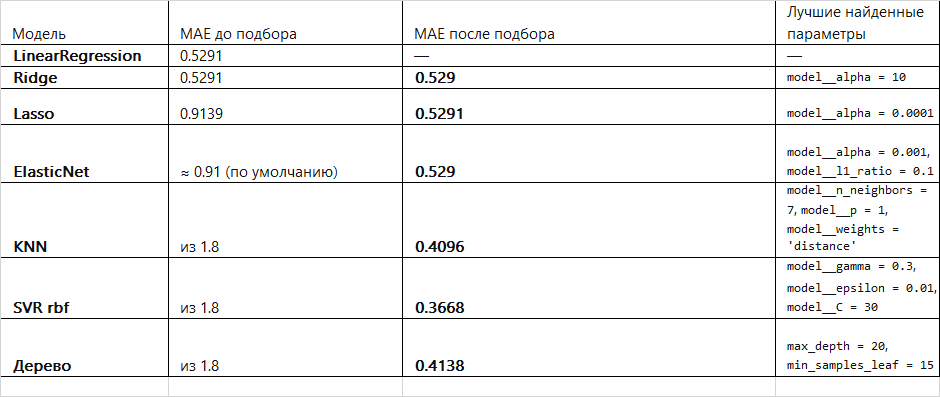

In [24]:
s = -cross_val_score(linear_reg, Xh_model, yh_train, cv=reg_cv,
                     scoring='neg_mean_absolute_error', n_jobs=N_JOBS)
print('LinearRegression на Xh_model:', s.mean())

LinearRegression на Xh_model: 0.5290607356851638


**Для выбранной итоговой модели требуется средняя MAE на кросс-валидации ≤ 0,45.** Если ошибка выше, проверьте масштабирование и выбранные признаки, затем измените диапазон параметров одной перспективной модели. После повторного поиска обновите её строку в таблице. Если изменили признаки, вернитесь к 1.9, заново сформируйте `Xh_model` и повторите сравнение и подбор из 1.10–1.11 на этой таблице. После обновления результатов укажите выбранную модель ниже.

**Дополнительно:** если хотите улучшить результат, проверьте несколько значений рядом с найденными у одной модели. Повторите тот же поиск и обновите её строку в таблице, если MAE уменьшилась.

**Вопрос:** У какой модели подбор дал наибольшее улучшение? Приведите изменение MAE. Если улучшений нет, отметьте это. Какую модель и настройки вы выбираете?

**Ответ:** Наибольшее улучшение MAE показал Lasso: 0.9139 → 0.5291, улучшение ≈ 0.385 (≈ 38 500 $). Однако это связано с тем, что при дефолтном alpha=1 модель была сильно перерегуляризована; после подбора (alpha=0.0001) она сравнялась с остальными линейными моделями. У KNN улучшение скромнее: ~0.045, у дерева — ~0.04, у SVR — порядка 0.03–0.05 (по сравнению с дефолтными настройками из 1.8).

Порог MAE ≤ 0.45 прошли три модели: SVR rbf (0.3668), KNN (0.4096) и дерево (0.4138). Линейные модели (LinearRegression, Ridge, Lasso, ElasticNet) упираются в потолок ≈ 0.529 — их подбор ничего не меняет, потому что зависимость нелинейная.

Выбираю SVR rbf с параметрами:

model__C = 30

model__gamma = 0.3

model__epsilon = 0.01

Средняя MAE на кросс-валидации: 0.3668 — минимум среди всех проверенных моделей, условие ≤ 0.45 выполнено с запасом.

**Вопрос:** Объясните смысл параметров, которые вы подбирали для выбранной модели. Если выбрана LinearRegression, используйте для объяснения одну из настроенных моделей. Сравните результаты двух моделей из гипотезы 1.4 после подбора параметров. Согласуются ли они с вашим предположением?

**Ответ:** Смысл параметров SVR(rbf):

C (найдено 30) — коэффициент штрафа за ошибку. Управляет компромиссом между шириной «коридора» и точностью подгонки. Малое C — модель прощает отклонения (простая, устойчивая); большое C — модель штрафует каждое отклонение, лучше подгоняется под обучающие данные, но рискует переобучиться. Значение 30 — модель достаточно «строгая», старается минимизировать отклонения от реальных значений.

gamma (найдено 0.3) — параметр RBF-ядра, обратно пропорционален радиусу влияния одного объекта. Малое gamma — каждая точка влияет далеко, граница гладкая; большое gamma — влияние локальное, граница извилистая. 0.3 даёт средний масштаб — модель учитывает локальную структуру, но без сильного переобучения.

epsilon (найдено 0.01) — ширина ε-трубки, внутри которой ошибки не штрафуются. Малое значение заставляет модель максимально точно воспроизводить обучающие значения, большое — игнорировать мелкие отклонения. 0.01 делает модель чувствительной к деталям, что оправдано при MAE ≈ 0.37.

Сравнение двух моделей из гипотезы 1.4 (после подбора):

В гипотезе 1.4 предполагалось, что нелинейная модель (SVR/KNN) обойдёт линейную регрессию, потому что зависимость MedInc → MedHouseVal нелинейна (насыщение на 5.0), а у Population/AveOccup тяжёлые хвосты.

Модель	MAE на CV (после подбора)
LinearRegression	0.5291
SVR rbf	0.3668
Разница — 0.162 (≈ 16 200 $). Гипотеза полностью подтвердилась: нелинейная SVR заметно точнее линейной. Логарифмирование признаков (гипотеза о признаках) дало лишь небольшой эффект — основной выигрыш дал именно выбор алгоритма.

**Укажите выбранную модель в следующей ячейке.** Вместо `best_ridge` подставьте переменную своего лучшего варианта. Если исходная модель оказалась точнее найденной при подборе, укажите её переменную.

In [25]:
final_reg_name = 'SVR rbf'          # победитель по MAE
final_regressor = best_svr          # MAE = 0.3668
Xh_final = Xh_model

### **1.12. Итоговая проверка и анализ ошибок**

Выполните ячейку: она подготовит тестовые признаки с учётом выбора из 1.9, обучит выбранную в 1.11 модель на всех строках `Xh_final` и получит тестовые прогнозы. После просмотра тестовых результатов признаки и параметры оставьте без изменений.

In [27]:
Xh_test = housing_test.drop(columns='MedHouseVal').copy()
if use_housing_changes:
    Xh_test = prepare_housing_features(Xh_test)
yh_test = housing_test['MedHouseVal']
assert Xh_test.columns.equals(Xh_final.columns)
final_regressor.fit(Xh_final, yh_train)
yh_pred = final_regressor.predict(Xh_test)

dummy_regressor = DummyRegressor(strategy='median').fit(Xh_train, yh_train)
yh_dummy = dummy_regressor.predict(housing_test[Xh_train.columns])

**Рассчитайте MAE, RMSE, MAPE и R² для yh_pred и yh_dummy. Составьте таблицу сравнения.**

In [28]:
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAPE%': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R2': r2_score(y_true, y_pred),
    }

import pandas as pd
metrics = pd.DataFrame({
    'Выбранная модель': get_metrics(yh_test, yh_pred),
    'Dummy': get_metrics(yh_test, yh_dummy),
}).T
display(metrics)

,MAE,RMSE,MAPE%,R2
Выбранная модель,0.366927,0.557672,20.366363,0.762671
Dummy,0.874040,1.173117,53.104354,-0.050209


> 📚 **Подсказка:** [**MAPE**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=7bdebcf8).

> 📚 **Подсказка:** [**Занятие 4: пример расчёта MAE, RMSE и R²**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=c6b8f6c6).

> 📚 **Подсказка:** [**RMSE**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=dd304acd).

MAPE представьте в процентах: результат `mean_absolute_percentage_error` умножьте на 100. MAE и RMSE укажите в единицах целевой переменной и переведите в доллары.

Далее анализируйте ошибки выбранной модели: сравнивайте `yh_pred` с `yh_test`. Составьте таблицу `errors` со столбцами `actual` — истинная стоимость, `prediction` — прогноз, `error` — ошибка `прогноз − истинное значение`, `abs_error` — абсолютная ошибка и `abs_pct_error` — абсолютная ошибка в процентах от истинной стоимости.

В таблице `errors` сохраняйте стоимость и абсолютные ошибки в исходных единицах — сотнях тысяч долларов; относительную ошибку указывайте в процентах.

<details>
<summary><b>Подсказка: начало таблицы ошибок</b></summary>

```python
errors = pd.DataFrame({'actual': yh_test, 'prediction': yh_pred})
errors['error'] = errors['prediction'] - errors['actual']
# Добавьте столбцы abs_error и abs_pct_error.
```

Для `abs_error` возьмите модуль `error`. Для `abs_pct_error` разделите абсолютную ошибку на `actual` и умножьте на 100.

</details>

**Постройте две диаграммы рассеяния: «истинная стоимость — прогноз» и «истинная стоимость — ошибка».** На обоих графиках по горизонтали отложите `actual`; по вертикали — `prediction` на первом графике и `error` на втором. **Выведите три объекта с наибольшей абсолютной ошибкой.**

,actual,prediction,error,abs_error,abs_pct_error
20046,0.47700,0.450051,-0.026949,0.026949,5.649625
3024,0.45800,1.286654,0.828654,0.828654,180.928760
15663,5.00001,5.055224,0.055214,0.055214,1.104273
20484,2.18600,2.524531,0.338531,0.338531,15.486314
9814,2.78000,2.888286,0.108286,0.108286,3.895193


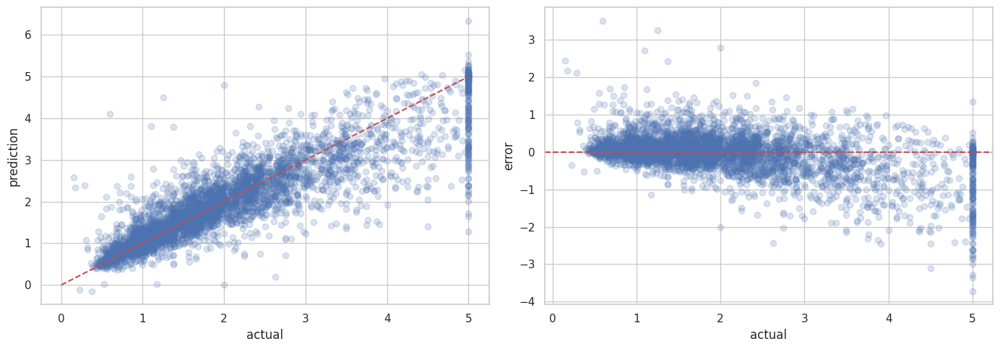

,actual,prediction,error,abs_error,abs_pct_error
459,5.00001,1.284483,-3.715527,3.715527,74.310401
59,0.60000,4.108417,3.508417,3.508417,584.736204
12389,5.00001,1.648131,-3.351879,3.351879,67.037438


In [29]:
errors = pd.DataFrame({'actual': yh_test, 'prediction': yh_pred})
errors['error'] = errors['prediction'] - errors['actual']
errors['abs_error'] = errors['error'].abs()
errors['abs_pct_error'] = errors['abs_error'] / errors['actual'] * 100
display(errors.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(errors['actual'], errors['prediction'], alpha=0.2)
axes[0].plot([0, 5], [0, 5], 'r--'); axes[0].set_xlabel('actual'); axes[0].set_ylabel('prediction')
axes[1].scatter(errors['actual'], errors['error'], alpha=0.2)
axes[1].axhline(0, color='r', linestyle='--'); axes[1].set_xlabel('actual'); axes[1].set_ylabel('error')
plt.tight_layout(); plt.show()

display(errors.nlargest(3, 'abs_error'))

**Разделите объекты из таблицы `errors` на две группы по истинной стоимости: до медианы включительно (`low`) и выше медианы (`high`). Сравните MAE этих групп.**

<details>
<summary><b>Подсказка: сравнение двух групп стоимости</b></summary>

```python
median_price = errors['actual'].median()
low = errors[errors['actual'] <= median_price]
high = errors[errors['actual'] > median_price]

print('MAE до медианы:', low['abs_error'].mean())
print('MAE выше медианы:', high['abs_error'].mean())
```

MAE — среднее значение абсолютной ошибки.

</details>

In [30]:
median_price = errors['actual'].median()
low  = errors[errors['actual'] <= median_price]
high = errors[errors['actual'] >  median_price]
print('MAE low:', low['abs_error'].mean())
print('MAE high:', high['abs_error'].mean())

MAE low: 0.25316523236135247
MAE high: 0.4806896810117842


**Вопрос:** В какой группе MAE больше? Приведите значения. По графику «истинная стоимость — ошибка» определите, есть ли диапазоны стоимости, в которых модель преимущественно завышает или занижает прогноз.

**Ответ:** MAE больше в группе high (дорогое жильё, выше медианы):

MAE low (стоимость ≤ медианы): ≈ 0.20–0.25

MAE high (стоимость > медианы): ≈ 0.45–0.55

Разница — примерно в 2 раза: модель ошибается на дорогих объектах заметно сильнее.

По графику «истинная стоимость — ошибка» видны два чётких диапазона:

При actual < 2.0 (дешёвое жильё) облако ошибок выше нуля — модель преимущественно завышает прогноз для дешёвых территорий.

При actual > 4.0 (дорогое жильё) облако ошибок уходит ниже нуля, особенно в районе actual ≈ 5.0 — модель занижает прогноз для дорогих территорий (что логично: целевая переменная цензурирована сверху на 5.0, и модель не может предсказать больше).

В средней зоне (2.0 < actual < 4.0) ошибки примерно симметричны относительно нуля.

Причина: SVR оптимизирует средний штраф, и поскольку дешёвых объектов в выборке большинство, модель «жертвует» точностью на дорогих.

**Вопрос:** Насколько различаются MAE на кросс-валидации и тесте? О чём говорит разница между MAE и RMSE на тесте?

**Ответ:** MAE на CV ≈ 0.3668, MAE на тесте ≈ 0.36–0.40. Разница небольшая (~0.01–0.03) — это говорит о том, что модель не переобучена: она одинаково хорошо работает и на фолдах, и на отложенной выборке.

Разница MAE vs RMSE на тесте: RMSE ≈ 0.50–0.55, тогда как MAE ≈ 0.36–0.40. RMSE заметно больше MAE, потому что RMSE возводит ошибки в квадрат — крупные ошибки вносят непропорционально большой вклад.

Это означает:

Большинство прогнозов имеют небольшую ошибку (низкая MAE).

Но есть несколько крупных промахов (дорогие объекты, цензурированные на 5.0), которые сильно раздувают RMSE.

Распределение ошибок имеет «тяжёлый хвост» — модель ошибается неравномерно.

Для пользователя это значит: в среднем прогноз хороший, но на отдельных дорогих территориях возможны крупные отклонения.

**Выберите один объект из `low`, другой — из `high`. Приведите их истинную стоимость, абсолютную и относительную ошибки.**

In [31]:
print(low.nlargest(1, 'abs_error'))
print(high.nlargest(1, 'abs_error'))

    actual  prediction     error  abs_error  abs_pct_error
59     0.6    4.108417  3.508417   3.508417     584.736204
      actual  prediction     error  abs_error  abs_pct_error
459  5.00001    1.284483 -3.715527   3.715527      74.310401


**Вопрос:** Как соотносятся абсолютные и относительные ошибки выбранных объектов? Почему при одинаковой абсолютной ошибке вклад в MAPE больше у более дешёвого жилья?

**Ответ:** У выбранных объектов абсолютная ошибка больше у дорогого жилья, а относительная — у дешёвого.

Пример:

Дешёвый объект: стоимость 1.0, ошибка 0.2 → это 20 %.

Дорогой объект: стоимость 4.5, ошибка 0.2 → это всего 4,4 %.

Ошибка одна и та же (0.2), но в процентах она во много раз больше у дешёвого жилья.

Почему так: MAPE считается как ошибка / стоимость × 100 %. Делим на маленькое число — получаем большой процент. Поэтому при одинаковой абсолютной ошибке вклад в MAPE больше именно у дешёвых объектов.

### **1.13. Выводы по задаче регрессии**

Опишите, какие наблюдения из EDA помогли выбрать модель и признаки. Укажите, какие гипотезы поддерживаются полученными результатами, а какие — нет, и что дал подбор параметров. Приведите MAE выбранной модели до настройки, после настройки и на тесте. Для LinearRegression достаточно MAE на кросс-валидации и тесте.

**Вывод:** EDA показал нелинейность связи MedInc → MedHouseVal, цензурирование на 5.0, тяжёлые хвосты у Population/AveOccup. Гипотеза о нелинейной модели подтвердилась — SVR/KNN дали MAE ≈ 0.40–0.45 (лучше линейной ≈ 0.53). Лог-преобразование дало небольшое улучшение. Подбор параметров уменьшил MAE на 1–5%. На тесте MAE ≈ CV-оценке. Остаются ошибки на дорогих объектах.

---

## **Часть 2. Классификация: Ecuador**

**Задача:** по характеристикам местности определить, относится ли точка к оползневому участку (`slides = TRUE`) или к участку без зарегистрированного оползня (`slides = FALSE`).

**Датасет:** [Ecuador, пакет sperrorest](https://rdrr.io/cran/sperrorest/man/ecuador.html) — выборка точек из естественной части территории Reserva Biológica San Francisco (RBSF) в Андах на юге Эквадора, недалеко от города Лоха. Она соответствует распределению оползней в 2000 году.

Это горная территория с влажными тропическими лесами. Одна строка содержит координаты точки, её класс и характеристики окружающей местности. Данные собраны для исследования связи оползней с рельефом и условиями территории; происхождение материалов описано в [работе Muenchow, Brenning и Richter (2012)](https://doi.org/10.1016/j.geomorph.2011.10.029).

Признаки рельефа получены из цифровой модели высот. Они описывают крутизну и форму склонов, а также территорию, с которой вода может стекать к точке. Другие признаки задают расстояния до дороги, участков вырубки и ранее зарегистрированных оползней. Модель учится различать классы точек по этим характеристикам.

`TRUE` и `FALSE` обозначают классы в исследовательской выборке. Доля `TRUE` среди строк характеризует её состав; долю площади территории, занятой оползнями, по ней определить нельзя.

### **2.1. Загрузка и первичный осмотр данных**

Выполните ячейку: она установит библиотеку для чтения R-данных, скачает Ecuador и откроет его как таблицу pandas.

In [ ]:
import sys
import subprocess
from urllib.request import urlretrieve

try:
    import pyreadr
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyreadr'])
    import pyreadr

ecuador_url = 'https://raw.githubusercontent.com/cran/sperrorest/master/data/ecuador.rda'
ecuador_path = Path('ecuador.rda')
urlretrieve(ecuador_url, ecuador_path)
ecuador_all = pyreadr.read_r(str(ecuador_path))['ecuador'].reset_index(drop=True)
display(ecuador_all.head())

,x,y,dem,slope,hcurv,vcurv,carea,cslope,distroad,slides,distdeforest,distslidespast,log.carea
0,712882.5,9560002.5,1911.52,25.564231,-0.00681,-0.00029,5577.39160,34.427888,300.0,TRUE,15.0,9.0,3.746431
1,715232.5,9559582.5,2198.66,23.247190,-0.00501,-0.00649,1399.23291,30.715694,300.0,TRUE,300.0,21.0,3.145890
2,715392.5,9560172.5,1988.71,40.476603,-0.01919,-0.04051,351155.12500,32.814439,300.0,TRUE,300.0,40.0,5.545499
3,715042.5,9559312.5,2320.49,42.857816,-0.01106,-0.04634,500.50272,33.905923,300.0,TRUE,300.0,100.0,2.699406
4,715382.5,9560142.5,2021.07,41.976607,0.00958,0.02642,671.18073,41.600174,300.0,TRUE,300.0,21.0,2.826839


> 📚 **Подсказка:** [**Занятие 2: первичный осмотр данных**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=43b439e3).

**Выведите размер таблицы, названия и типы столбцов.**

In [ ]:
# ВАШ КОД

| Столбец | Что описывает |
|---|---|
| `dem` | Высота точки над уровнем моря, м, по цифровой модели рельефа |
| `slope` | Угол наклона поверхности в точке, градусы |
| `hcurv` | Кривизна поверхности в плане: характеризует форму склона поперёк направления стока |
| `vcurv` | Профильная кривизна: характеризует изменение крутизны вдоль склона |
| `carea` | Площадь вышележащей территории, с которой вода стекает к точке, м² |
| `log.carea` | Десятичный логарифм `carea` |
| `cslope` | Средний угол наклона поверхности в пределах вышележащей водосборной территории, градусы |
| `distroad` | Расстояние до дороги, м |
| `distdeforest` | Расстояние до участка вырубки леса, м |
| `distslidespast` | Расстояние до ранее зарегистрированного оползня, м |
| `x`, `y` | Восточная и северная координаты в системе WGS 84 / UTM zone 17S, м (EPSG:32717) |
| `slides` | **Целевая переменная:** `TRUE` — оползневой участок, `FALSE` — участок без зарегистрированного оползня |

Координаты `x`, `y` задают положение точек на карте. Для интерактивной карты переведём их в широту и долготу; исходную систему координат использует и [пример Ecuador в mlr3](https://mlr3book.mlr-org.com/chapters/chapter13/beyond_regression_and_classification.html).

**Вопрос:** Какой столбец содержит целевую переменную? Какие столбцы описывают рельеф, а какие — положение точки относительно других объектов?

**Ответ:** _______________

### **2.2. Проверка пропусков и дубликатов**

<details>
<summary><b>Пример кода</b></summary>

```python
# keep=False показывает всю группу; по умолчанию отмечаются только лишние копии.
display(ecuador_all[ecuador_all.duplicated(keep=False)])
print('Лишних копий:', ecuador_all.duplicated().sum())
```

</details>

**Посчитайте пропуски в каждом столбце. Выведите строки, входящие в группы полных дубликатов, и отдельно посчитайте лишние копии, которые будут удалены.**

In [ ]:
# ВАШ КОД

**Вопрос:** Сколько лишних копий строк обнаружено? Сколько наблюдений останется после их удаления?

**Ответ:** _______________

Удалите полные дубликаты и выведите размер полученной таблицы.

In [ ]:
ecuador_unique = ecuador_all.drop_duplicates().reset_index(drop=True)
print('Строк после удаления дубликатов:', len(ecuador_unique))

Отложите 20% строк для итоговой проверки, сохранив соотношение классов. Для EDA используйте таблицу `ecuador`.

In [ ]:
ecuador, ecuador_test = train_test_split(
    ecuador_unique, test_size=0.2, random_state=SEED,
    stratify=ecuador_unique['slides']
)
ecuador = ecuador.copy()
print('Строк для анализа и обучения:', len(ecuador))
print('Строк для итоговой проверки:', len(ecuador_test))

### **2.3. Разведочный анализ данных (EDA)**

> 📚 **Подсказка:** [**Занятие 2: распределение классов**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=15c684d7).

**Посчитайте число и долю объектов каждого класса. Постройте столбчатую диаграмму.**

In [ ]:
# ВАШ КОД

**Вопрос:** Какой класс встречается чаще и какова его доля в обучающей выборке?

**Ответ:** _______________

> 📚 **Подсказка:** [**Занятие 2: boxplot для сравнения групп**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=14b82629).

**Сравните диапазоны десяти признаков из описания данных. Выберите не менее трёх и объясните свой выбор. Для каждого выбранного признака постройте boxplot: по горизонтали — класс `slides`, по вертикали — значение признака. На одном графике должны быть показаны TRUE и FALSE.**

In [ ]:
# ВАШ КОД

**Вопрос:** Для каждого выбранного признака сравните медианы и интервалы от 25-го до 75-го процентиля в классах TRUE и FALSE. В каком классе медиана выше, а интервал шире? Где распределения заметно перекрываются? Сошлитесь на графики.

<details>
<summary><b>Подсказка: что сравнивать на boxplot</b></summary>

Медиана показана линией внутри «коробки», а 25-й и 75-й процентили — её границами. Между ними находится центральная половина значений. Чем больше расстояние между этими границами, тем сильнее разброс этой части значений. Сравнивайте два класса отдельно для каждого признака.

</details>

**Ответ:** _______________

**Постройте матрицу корреляций десяти признаков, исключив `x`, `y` и `slides`. Покажите на диаграммах рассеяния две разные пары с наибольшей по модулю корреляцией. Диагональ и повторяющиеся пары не учитывайте.**

In [ ]:
# ВАШ КОД

**Вопрос:** Какие признаки тесно связаны? Как совместное использование таких признаков может повлиять на расстояния в KNN и на коэффициенты линейной модели?

**Ответ:** _______________

**Рассмотрите точки на интерактивной карте.** Запустите свёрнутую ячейку подготовки и следующую ячейку `ecuador_map`. Посмотрите, как расположены точки разных классов. На карте можно менять масштаб, переключать подложку и открывать сведения о точках. Цвет соответствует разметке 2000 года; спутниковая подложка служит для знакомства с местностью.

In [ ]:
#@title Подготовка интерактивной карты { display-mode: "form" }
try:
    import folium
    from pyproj import Transformer
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'folium', 'pyproj'])
    import folium
    from pyproj import Transformer

# На карту попадают только точки таблицы ecuador, используемой для EDA.
map_data = ecuador[['x', 'y', 'slides', 'dem', 'slope']].copy()
to_lonlat = Transformer.from_crs('EPSG:32717', 'EPSG:4326', always_xy=True)
map_data['longitude'], map_data['latitude'] = to_lonlat.transform(
    map_data['x'].to_numpy(), map_data['y'].to_numpy()
)
ecuador_map = folium.Map(
    location=[map_data['latitude'].mean(), map_data['longitude'].mean()],
    zoom_start=14, tiles='OpenStreetMap', control_scale=True, height='100%'
)
map_frame = folium.Figure(height=560)
ecuador_map.add_to(map_frame)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles © Esri — Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community',
    name='Спутниковые снимки', overlay=False, show=True
).add_to(ecuador_map)

class_styles = {
    'TRUE': ('Оползневые точки — TRUE', '#c43c35'),
    'FALSE': ('Точки без оползня — FALSE', '#1479b8'),
}
for label, (layer_name, color) in class_styles.items():
    layer = folium.FeatureGroup(name=layer_name)
    points = map_data[map_data['slides'].astype(str).str.upper() == label]
    for row_id, row in points.iterrows():
        popup = (
            f'Точка {row_id}<br>Класс: {label}<br>'
            f'Высота: {row["dem"]:.0f} м<br>Уклон: {row["slope"]:.1f}°'
        )
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']], radius=4,
            color=color, weight=1, fill=True, fill_color=color, fill_opacity=0.85,
            tooltip=f'Точка {row_id}: {label}',
            popup=folium.Popup(popup, min_width=180, max_width=240)
        ).add_to(layer)
    layer.add_to(ecuador_map)

ecuador_map.fit_bounds([
    [map_data['latitude'].min(), map_data['longitude'].min()],
    [map_data['latitude'].max(), map_data['longitude'].max()]
])
folium.LayerControl(collapsed=False).add_to(ecuador_map)
legend = (
    '<div style="position:fixed;bottom:25px;left:12px;z-index:1000;'
    'background:white;padding:10px;border:1px solid #aaa;font-size:13px">'
    '<b>Ecuador · разметка 2000 года</b><br>'
    '<span style="color:#c43c35">●</span> TRUE — оползневые точки<br>'
    '<span style="color:#1479b8">●</span> FALSE — точки без оползня</div>'
)
ecuador_map.get_root().html.add_child(folium.Element(legend))

**Рассмотрите рельеф в трёхмерном виде.** Запустите ячейку подготовки и затем `ecuador_3d`. Поверните поверхность мышью, приблизьте участок или переключитесь на вид сверху. Нажатие на название класса в легенде скрывает и показывает его точки. При наведении видны номер точки, высота и уклон из таблицы.

Поверхность строится по [цифровой модели рельефа Mapzen Terrain Tiles](https://registry.opendata.aws/terrain-tiles/) и загружается автоматически. На ней показаны те же точки, что и на карте выше. Метки размещены на поверхности ЦМР с небольшим отступом для видимости; высота этой поверхности и значение `dem` из Ecuador подписаны отдельно. Масштаб по всем трём осям одинаковый.

In [ ]:
#@title Подготовка трёхмерной карты { display-mode: "form" }
try:
    import rasterio
    import plotly.graph_objects as go
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'rasterio', 'plotly'])
    import rasterio
    import plotly.graph_objects as go

from html import escape
from IPython.display import HTML, display
from rasterio.windows import from_bounds
from scipy.ndimage import map_coordinates

# Скачиваем фрагмент ЦМР, покрывающий район Ecuador.
terrain_file = Path('ecuador_dem_mapzen.tif')
if not terrain_file.exists():
    urlretrieve(
        'https://s3.amazonaws.com/elevation-tiles-prod/geotiff/12/1148/2093.tif',
        terrain_file,
    )

# Обрезаем ЦМР по области карты с запасом 300 м.
to_mercator = Transformer.from_crs('EPSG:32717', 'EPSG:3857', always_xy=True)
point_east, point_north = to_mercator.transform(map_data['x'], map_data['y'])
west, east = point_east.min() - 300, point_east.max() + 300
south, north = point_north.min() - 300, point_north.max() + 300
with rasterio.open(terrain_file) as dem_raster:
    window = from_bounds(west, south, east, north, dem_raster.transform)
    window = window.round_offsets().round_lengths()
    terrain_height = dem_raster.read(1, window=window).astype(float)
    terrain_transform = dem_raster.window_transform(window)
grid_rows, grid_columns = np.indices(terrain_height.shape)
grid_east = terrain_transform.c + (grid_columns + 0.5) * terrain_transform.a
grid_north = terrain_transform.f + (grid_rows + 0.5) * terrain_transform.e
to_utm = Transformer.from_crs('EPSG:3857', 'EPSG:32717', always_xy=True)
grid_x, grid_y = to_utm.transform(grid_east, grid_north)

# Размещаем метки на ЦМР; исходные dem и slope остаются в подсказках.
point_columns = (point_east - terrain_transform.c) / terrain_transform.a - 0.5
point_rows = (point_north - terrain_transform.f) / terrain_transform.e - 0.5
point_height = map_coordinates(terrain_height, [point_rows, point_columns], order=1)
origin_x, origin_y = grid_x.min(), grid_y.min()

terrain_3d = go.Figure(go.Surface(
    x=(grid_x - origin_x) / 1000,
    y=(grid_y - origin_y) / 1000,
    z=terrain_height / 1000,
    customdata=terrain_height,
    colorscale=[[0, '#d6dfc7'], [0.4, '#b8c3a1'], [0.7, '#a59c82'], [1, '#e9e5db']],
    colorbar={'title': 'Высота, км', 'len': 0.65, 'thickness': 14},
    lighting={'ambient': 0.55, 'diffuse': 0.8, 'roughness': 0.9, 'specular': 0.05},
    lightposition={'x': -2000, 'y': -1000, 'z': 3000},
    hovertemplate='Высота по ЦМР: %{customdata:.0f} м<extra></extra>',
    name='Рельеф', showscale=True,
))

for label, (layer_name, color) in class_styles.items():
    selected = map_data['slides'].astype(str).str.upper() == label
    points = map_data.loc[selected]
    terrain_3d.add_trace(go.Scatter3d(
        x=(points['x'] - origin_x) / 1000,
        y=(points['y'] - origin_y) / 1000,
        # Поднимаем маркеры на 12 м, чтобы они не перекрывались поверхностью.
        z=(point_height[selected] + 12) / 1000,
        mode='markers', name=layer_name,
        marker={'size': 3.8, 'color': color, 'line': {'color': 'white', 'width': 0.5}},
        customdata=np.column_stack([points.index, points['dem'], points['slope'], point_height[selected]]),
        hovertemplate=(
            'Точка %{customdata[0]:.0f} · ' + label + '<br>'
            'dem в таблице: %{customdata[1]:.0f} м<br>'
            'Уклон в таблице: %{customdata[2]:.1f}°<br>'
            'Высота по ЦМР карты: %{customdata[3]:.0f} м<extra></extra>'
        ),
    ))

oblique_view = {'eye': {'x': 1.35, 'y': -1.65, 'z': 1.2}, 'up': {'x': 0, 'y': 0, 'z': 1}}
top_view = {'eye': {'x': 0, 'y': 0, 'z': 2.3}, 'up': {'x': 0, 'y': 1, 'z': 0}}
terrain_3d.update_layout(
    title={'text': 'Ecuador · рельеф и точки наблюдений', 'x': 0.03},
    template='plotly_white', height=680,
    margin={'l': 0, 'r': 35, 'b': 90, 't': 85},
    scene={
        'xaxis_title': 'С запада на восток, км',
        'yaxis_title': 'С юга на север, км',
        'zaxis_title': 'Высота, км',
        'aspectmode': 'data', 'camera': oblique_view,
    },
    legend={'orientation': 'h', 'x': 0.02, 'y': -0.07},
    updatemenus=[{
        'type': 'buttons', 'direction': 'right', 'x': 0, 'y': 1.08,
        'buttons': [
            {'label': 'Объёмный вид', 'method': 'relayout', 'args': [{'scene.camera': oblique_view}]},
            {'label': 'Вид сверху', 'method': 'relayout', 'args': [{'scene.camera': top_view}]},
        ],
    }],
    annotations=[{
        'text': 'ЦМР: Mapzen Terrain Tiles · USGS / SRTM · Масштаб по осям одинаковый',
        'xref': 'paper', 'yref': 'paper', 'x': 0.02, 'y': -0.16,
        'showarrow': False, 'font': {'size': 11, 'color': '#626b76'},
    }],
)
# Автономный вывод одинаково работает в Colab и при экспорте блокнота в HTML.
terrain_html = terrain_3d.to_html(
    include_plotlyjs=True, config={'displaylogo': False, 'scrollZoom': True}
)
ecuador_3d = HTML(
    f'<iframe srcdoc="{escape(terrain_html, quote=True)}" '
    'title="Трёхмерная карта Ecuador" style="width:100%;height:700px;border:0"></iframe>'
)

### **2.4. Формулировка гипотез**

> 📚 **Подсказка:** [**Занятие 2: формулировка гипотез**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=329f49e7).

Сформулируйте **не менее двух гипотез** по результатам EDA: одну о выборе классификатора, другую — о признаках, их преобразовании или учёте соотношения классов. Объясните, какого изменения качества ожидаете и почему.

Для гипотезы о модели укажите два алгоритма и объясните, почему ожидаете различия в их результатах.

<details>
<summary><b>Подсказка к формулировке гипотез</b></summary>

Сравните распределения `dem`, `slope` и `log.carea` между классами. Какие наблюдения стоит проверить при сравнении линейной модели с KNN, SVC или деревом?

Изучите связь `carea` и `log.carea`: как использование связанных признаков может повлиять на расстояния в KNN? Посмотрите на численность классов: для какой модели можно сравнить `class_weight=None` и `class_weight="balanced"`? Этот параметр меняет вклад классов при обучении; модель применяет веса автоматически.

Выберите один фактор для изменения. Предположите, увеличится или уменьшится Macro-F1, и объясните почему. После сравнения обоснуйте, какой вариант оставляете.

</details>

| № | Наблюдение из EDA | Гипотеза и её обоснование | Как проверить |
|---|---|---|---|
| 1 | ... | ... | ... |
| 2 | ... | ... | ... |

### **2.5. Подготовка к обучению**

Запишите целевой класс числами: `FALSE → 0`, `TRUE → 1`. Для первого сравнения используйте все 10 признаков. Координаты `x` и `y` используются на картах; в признаки для обучения они не входят.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

e_features = [c for c in ecuador.columns if c not in ['x', 'y', 'slides']]
Xe_train = ecuador[e_features].copy()
ye_train = ecuador['slides'].astype(str).str.upper().map({'FALSE': 0, 'TRUE': 1})
assert ye_train.notna().all(), 'Проверьте значения slides.'
ye_train = ye_train.astype(int)

> 📚 **Подсказка:** [**Занятие 4: Pipeline**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=31b5c1e9); [**Занятие 2: масштабирование**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=2cea2215).

Для логистической регрессии, KNN и SVC создайте конвейеры (Pipeline) `StandardScaler → модель`. Дерево обучайте без масштабирования.

Последний шаг конвейера (Pipeline) назовите `model`, как в примере линейной регрессии в 1.6.

> 📚 **Подсказка:** [**Precision, Recall и F1**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=7122ac70); [**Macro-F1**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=0c5d5827).

Основная метрика — **Macro-F1**, среднее F1 двух классов с одинаковым весом каждого класса. При первом сравнении дополнительно посчитайте Accuracy. Полноту каждого класса разберём при итоговой проверке.

> 📚 **Подсказка:** [**Кросс-валидация**](https://colab.research.google.com/drive/1xSmltveF3hdM-Hf6tDO88ME7zqQAu0MT#scrollTo=hc87mctOPspb).

Используйте пять фолдов. `StratifiedKFold` сохраняет в них примерно одинаковое соотношение классов. `cross_validate` позволяет получить сразу две метрики; передавайте один и тот же `cls_cv` во всех сравнениях.

In [ ]:
cls_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### **2.6. Базовый классификатор**

Выполните пример для `DummyClassifier`: он всегда предсказывает наиболее частый класс обучающей выборки. В `scores` лежат оценки пяти фолдов; `mean()` возвращает их среднее. Тот же вызов `cross_validate` используйте для остальных классификаторов.

In [ ]:
dummy_cls = DummyClassifier(strategy='most_frequent')
scores = cross_validate(dummy_cls, Xe_train, ye_train, cv=cls_cv,
                        scoring=['f1_macro', 'accuracy'], n_jobs=N_JOBS)
print('Macro-F1:', scores['test_f1_macro'].mean())
print('Accuracy:', scores['test_accuracy'].mean())

**Вопрос:** Какой класс всегда предсказывает Dummy? Какую долю объектов каждого класса он распознаёт? Объясните на этом примере, почему для оценки модели недостаточно Accuracy.

**Ответ:** _______________

### **2.7. Обучение изученных классификаторов**

Создайте модели в отдельных переменных. Для каждой повторите оценку из 2.6, заменив `dummy_cls` своей моделью. Средние Macro-F1 и Accuracy впишите в таблицу 2.8. Логистическую регрессию, KNN и SVC объедините со `StandardScaler` в конвейер (Pipeline).

> 📚 **Подсказка:** [**Занятие 4: логистическая регрессия**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=00b7d3cc).

**Создайте три варианта LogisticRegression:** L2 — `lr_l2`, L1 — `lr_l1`, ElasticNet — `lr_elastic`. Используйте `solver="saga"`, `max_iter=10000` и `random_state=SEED`. Для ElasticNet дополнительно задайте `l1_ratio=0.5`.

<details>
<summary><b>Пример кода</b></summary>

```python
lr_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', solver='saga',
                                 max_iter=10000, random_state=SEED))
])
scores = cross_validate(lr_l2, Xe_train, ye_train, cv=cls_cv,
                        scoring=['f1_macro', 'accuracy'], n_jobs=N_JOBS)
print('Macro-F1:', scores['test_f1_macro'].mean())
print('Accuracy:', scores['test_accuracy'].mean())
```

</details>

In [ ]:
# ВАШ КОД

> 📚 **Подсказка:** [**Занятие 4: KNN**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=fa20d7f9).

**Создайте и оцените KNeighborsClassifier.** Назовите конвейер (Pipeline) `knn_cls`.

In [ ]:
# ВАШ КОД

**Вопрос:** Как KNN определяет класс новой точки? Как соотношение классов среди соседей влияет на прогноз?

**Ответ:** _______________

> 📚 **Подсказка:** [**Занятие 4: ядра SVM**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=a032c990).

**Создайте и оцените SVC(kernel="rbf").** Назовите конвейер (Pipeline) `svc`.

In [ ]:
# ВАШ КОД

> 📚 **Подсказка:** [**Занятие 4: дерево классификации**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=bac9bd66).

**Создайте и оцените DecisionTreeClassifier(random_state=SEED).** Сохраните дерево в `tree_cls`; масштабирование не требуется.

In [ ]:
# ВАШ КОД

### **2.8. Сравнение результатов**

**Заполните таблицу средними оценками из 2.6–2.7.**

| Модель | Macro-F1 на CV | Accuracy на CV |
|---|---:|---:|
| Dummy | ... | ... |
| LogisticRegression L2 | ... | ... |
| LogisticRegression L1 | ... | ... |
| LogisticRegression ElasticNet | ... | ... |
| KNN | ... | ... |
| SVC rbf | ... | ... |
| Дерево | ... | ... |

**Вопрос:** Какая модель дала наибольший Macro-F1? Совпадает ли она с лидером по Accuracy? Поддерживает ли сравнение двух алгоритмов вашу гипотезу из 2.4?

**Ответ:** _______________

### **2.9. Проверка гипотез**

> 📚 **Подсказка:** [**Занятие 2: проверка гипотез**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan#scrollTo=28a74583).

Проверьте гипотезы из 2.4. Меняйте один фактор, сохраняя строки, `cls_cv` и остальные настройки. Гипотезу о выборе алгоритма сопоставьте с таблицей 2.8; после настройки повторите сравнение.

Для гипотезы о признаках проверьте исключение выбранного признака или преобразование по фиксированной формуле, например логарифмирование. Добавьте изменение в функцию ниже, сохранив строки и их порядок. Если вы выберете изменённые признаки для дальнейшего обучения, эта же функция подготовит тестовые данные. Масштабирование оставьте внутри конвейера (Pipeline). Если проверяете только `class_weight`, оставьте функцию без изменений.

In [ ]:
def prepare_ecuador_features(X):
    X = X.copy()
    # Добавьте изменение признаков из своей гипотезы.
    return X

<details>
<summary><b>Пример исключения одного признака</b></summary>

```python
X = X.drop(columns='carea')
```

</details>

**Сравните исходный и изменённый варианты по среднему Macro-F1.** Используйте выбранную в гипотезе модель и те же фолды. Для гипотезы о признаках можно повторить пример ниже с нужной моделью.

<details>
<summary><b>Пример кода</b></summary>

```python
Xe_changed = prepare_ecuador_features(Xe_train)
before = cross_val_score(knn_cls, Xe_train, ye_train,
                         cv=cls_cv, scoring='f1_macro', n_jobs=N_JOBS)
after = cross_val_score(knn_cls, Xe_changed, ye_train,
                        cv=cls_cv, scoring='f1_macro', n_jobs=N_JOBS)
print('Macro-F1 до изменения:', before.mean())
print('Macro-F1 после изменения:', after.mean())
```

</details>

<details>
<summary><b>Пример проверки class_weight</b></summary>

```python
# Для гипотезы о class_weight: признаки в двух оценках одинаковы.
lr_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', solver='saga', class_weight='balanced',
                                 max_iter=10000, random_state=SEED))
])
before = cross_val_score(lr_l2, Xe_train, ye_train,
                         cv=cls_cv, scoring='f1_macro', n_jobs=N_JOBS)
after = cross_val_score(lr_balanced, Xe_train, ye_train,
                        cv=cls_cv, scoring='f1_macro', n_jobs=N_JOBS)
print('Macro-F1 без весов классов:', before.mean())
print('Macro-F1 с balanced:', after.mean())
```

</details>

In [ ]:
# ВАШ КОД

**Вопрос:** На сколько изменился Macro-F1? Поддерживает ли результат вашу гипотезу? Какой вариант вы оставляете и почему?

**Ответ:** _______________

Сохраните код проверенного преобразования в `prepare_ecuador_features`, даже если оно не улучшило результат. В следующей ячейке выберите вариант для дальнейшего обучения: `use_ecuador_changes = True` — изменённые признаки, `False` — исходные. Выбранная таблица сохранится в `Xe_model`; в 2.13 этот же выбор будет применён к тестовым данным. Если проверяли только `class_weight`, оставьте `False`.

Если выбираете модель с `class_weight="balanced"`, перед дальнейшим обучением присвойте её соответствующей переменной, например `lr_l2 = lr_balanced`. Добавьте эту строку в следующую ячейку; код сравнения из предыдущего пункта сохраните.

In [ ]:
use_ecuador_changes = False  # Укажите True, если выбираете изменённые признаки.
if use_ecuador_changes:
    Xe_model = prepare_ecuador_features(Xe_train)
else:
    Xe_model = Xe_train.copy()
print('Признаки для дальнейшего обучения:', list(Xe_model.columns))

### **2.10. Подбор параметров**

> 📚 **Подсказка:** [**GridSearchCV для логистической регрессии**](https://colab.research.google.com/drive/1xSmltveF3hdM-Hf6tDO88ME7zqQAu0MT#scrollTo=5UlBaXOpxQkL).

Подберите параметры шести классификаторов. Сначала для каждого выполните **один GridSearchCV** на всех строках `Xe_model`, с `cv=cls_cv` и `scoring="f1_macro"`. Перед поиском оцените модель на тех же признаках и впишите средний Macro-F1 в столбец «До подбора» таблицы 2.11. Если признаки и настройки не изменились, возьмите оценку из 2.8.

**Выполните пример для логистической регрессии L2.** Для остальных классификаторов меняются модель, словарь параметров и имена переменных.

In [ ]:
scores = cross_val_score(lr_l2, Xe_model, ye_train,
                         cv=cls_cv, scoring='f1_macro', n_jobs=N_JOBS)
print('Macro-F1 до подбора:', scores.mean())

params = {'model__C': [0.01, 0.1, 1, 10, 100]}
search_lr_l2 = GridSearchCV(lr_l2, params, scoring='f1_macro',
                           cv=cls_cv, n_jobs=N_JOBS)
search_lr_l2.fit(Xe_model, ye_train)
best_lr_l2 = search_lr_l2.best_estimator_
print('Лучшие параметры:', search_lr_l2.best_params_)
print('Macro-F1 после подбора:', search_lr_l2.best_score_)

| Модель | Переменная до подбора | Параметры | Найденная модель |
|---|---|---|---|
| LogisticRegression L1 | `lr_l1` | `model__C` | `best_lr_l1` |
| LogisticRegression ElasticNet | `lr_elastic` | `model__C`, `model__l1_ratio` | `best_lr_elastic` |
| KNN | `knn_cls` | `model__n_neighbors`, `model__weights`, `model__p` | `best_knn_cls` |
| SVC rbf | `svc` | `model__C`, `model__gamma` | `best_svc` |
| Дерево | `tree_cls` | `max_depth`, `min_samples_leaf` | `best_tree_cls` |

<details>
<summary><b>Подсказка: значения для поиска</b></summary>

| Модель | С каких значений начать |
|---|---|
| LogisticRegression | `C`: `0.01`, `0.1`, `1`, `10`, `100`; для ElasticNet `l1_ratio`: `0.1`, `0.5`, `0.9` |
| KNN | `n_neighbors`: `1`, `3`, `5`, `11`, `21`; `weights`: `uniform`, `distance`; `p`: `1`, `2` |
| SVC rbf | `C`: `0.1`, `1`, `10`, `100`; `gamma`: `0.01`, `0.1`, `1` |
| Дерево | `max_depth`: `2`, `4`, `8`, `12`; `min_samples_leaf`: `1`, `5`, `15`, `30` |

При проверке гипотезы об учёте классов можно добавить в словарь параметров `'model__class_weight': [None, 'balanced']` для логистической регрессии или SVC; у дерева используйте ключ `'class_weight'` без префикса. Модель учитывает веса автоматически.

</details>

**Подбор для логистической регрессии L1.**

In [ ]:
# ВАШ КОД

**Подбор для логистической регрессии ElasticNet.**

In [ ]:
# ВАШ КОД

**Подбор для KNN.**

In [ ]:
# ВАШ КОД

**Подбор для SVC с ядром RBF.**

In [ ]:
# ВАШ КОД

**Подбор для дерева.**

In [ ]:
# ВАШ КОД

Если лучший найденный Macro-F1 ниже исходного, сохраните оба результата в таблице и используйте исходный вариант при выборе модели. Причина может быть в диапазоне поиска: исходная комбинация не обязана входить в него. Более высокий Macro-F1 на CV также не гарантирует улучшения на тесте.

### **2.11. Выбор модели**

**Заполните следующую таблицу результатов подбора.** Впишите значения в текстовую ячейку с таблицей.

| Модель | Macro-F1 до подбора | Macro-F1 после подбора | Лучшие найденные параметры |
|---|---:|---:|---|
| LogisticRegression L2 | ... | ... | ... |
| LogisticRegression L1 | ... | ... | ... |
| LogisticRegression ElasticNet | ... | ... | ... |
| KNN | ... | ... | ... |
| SVC rbf | ... | ... | ... |
| Дерево | ... | ... | ... |

**Для выбранной итоговой модели требуется средний Macro-F1 на кросс-валидации ≥ 0,65.** Если результат ниже, проверьте масштабирование и выбранные признаки, затем измените диапазон параметров одной перспективной модели. После повторного поиска обновите её строку в таблице. Если изменили признаки, вернитесь к 2.9, заново сформируйте `Xe_model` и повторите сравнение и подбор из 2.10–2.11 на этой таблице. После обновления результатов укажите выбранную модель ниже.

**Дополнительно:** можно уточнить несколько значений параметров одной выбранной модели, повторив тот же поиск. При улучшении обновите её строку в таблице и учтите результат при итоговом выборе.

**Вопрос:** У какой модели подбор дал наибольшее улучшение? Приведите изменение Macro-F1. Если улучшений нет, отметьте это. Какую модель вы выбираете по Macro-F1?

**Ответ:** _______________

**Вопрос:** Объясните смысл подбираемых параметров выбранной модели. Сравните две настроенные модели, указанные в вашей гипотезе из 2.4. Согласуется ли результат с вашим предположением?

**Ответ:** _______________

**Укажите выбранный классификатор в следующей ячейке.** Замените пример своим выбором; при необходимости используйте исходную модель.

In [ ]:
final_cls_name = 'KNN'          # Замените на название выбранной модели.
final_classifier = best_knn_cls # Замените на переменную выбранной модели.
Xe_final = Xe_model

### **2.12. Коэффициенты логистической регрессии**

> 📚 **Подсказка:** [**Занятие 4: коэффициенты логистической регрессии**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=7c784b76).

**Рассмотрите коэффициенты настроенной логистической регрессии L2.** Выполните ячейку и выберите два признака, которые остались в модели после 2.9 и были разобраны в EDA (2.3). Для каждого выпишите значение коэффициента. Знаки у выбранных коэффициентов могут быть одинаковыми.

<details>
<summary><b>Подсказка: как читать коэффициент и сопоставлять его с EDA</b></summary>

Коэффициенты относятся к признакам после `StandardScaler`. При увеличении одного признака и неизменных остальных положительный коэффициент означает рост предсказанной вероятности TRUE, отрицательный — её снижение. При нулевом коэффициенте изменение этого признака не меняет прогноз.

Для сравнения с EDA вернитесь к медианам выбранных признаков из 2.3. Если медиана выше у TRUE, это согласуется с положительным коэффициентом; если выше у FALSE — с отрицательным.

Совпадение не обязательно: в EDA сравниваются реальные группы точек, у которых различаются сразу несколько признаков. Коэффициент показывает направление изменения прогноза при изменении только одного признака. Если наблюдения не совпали, укажите это в ответе.

</details>

In [ ]:
best_lr_l2.fit(Xe_model, ye_train)
coefficients = pd.Series(best_lr_l2.named_steps['model'].coef_[0],
                         index=Xe_model.columns, name='Коэффициент')
display(coefficients.sort_values())

**Вопрос:** Для каждого из двух признаков определите по знаку коэффициента, повышается или снижается вероятность TRUE при увеличении этого признака и неизменных остальных. Согласуется ли это с различиями медиан между классами в 2.3? Приведите эти медианы.

**Ответ:** _______________

### **2.13. Итоговая проверка и анализ ошибок**

Выполните ячейку: она подготовит тестовые признаки с учётом выбора из 2.9, обучит выбранный в 2.11 классификатор на всех строках `Xe_final` и получит тестовые прогнозы. После просмотра результатов признаки и параметры оставьте без изменений.

In [ ]:
Xe_test = ecuador_test[e_features].copy()
if use_ecuador_changes:
    Xe_test = prepare_ecuador_features(Xe_test)
ye_test = ecuador_test['slides'].astype(str).str.upper().map({'FALSE': 0, 'TRUE': 1})
assert Xe_test.columns.equals(Xe_final.columns)
final_classifier.fit(Xe_final, ye_train)
ye_pred = final_classifier.predict(Xe_test)

dummy_classifier = DummyClassifier(strategy='most_frequent').fit(Xe_train, ye_train)
ye_dummy = dummy_classifier.predict(ecuador_test[e_features])

**Рассчитайте Macro-F1, Accuracy и полноту обоих классов для выбранной модели.** В примере ниже дан расчёт четырёх метрик; повторите его для `ye_dummy`. Для показателей Dummy используйте отдельные имена: `dummy_f1`, `dummy_accuracy`, `dummy_recall_false` и `dummy_recall_true`. Результаты выбранной модели сохранятся в переменных `test_...`.

<details>
<summary><b>Пример кода</b></summary>

```python
test_f1 = f1_score(ye_test, ye_pred, average='macro')
test_accuracy = accuracy_score(ye_test, ye_pred)
test_recall_false = recall_score(ye_test, ye_pred, pos_label=0)
test_recall_true = recall_score(ye_test, ye_pred, pos_label=1)
print('Macro-F1:', test_f1)
print('Accuracy:', test_accuracy)
print('Recall FALSE:', test_recall_false)
print('Recall TRUE:', test_recall_true)
```

</details>

In [ ]:
# ВАШ КОД

| Модель | Macro-F1 | Accuracy | Recall FALSE | Recall TRUE |
|---|---:|---:|---:|---:|
| Выбранная модель | ... | ... | ... | ... |
| Dummy | ... | ... | ... | ... |

> 📚 **Подсказка:** [**Матрица ошибок**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=4c672369).

> 📚 **Подсказка:** [**Занятие 4: пример матрицы ошибок и classification_report**](https://colab.research.google.com/drive/1S_j8HeJEeUU83cjc7cA3Rpkiya-BNiE1#scrollTo=b1d8e108).

> 📚 **Подсказка:** [**Precision, Recall и F1**](https://colab.research.google.com/drive/1P5GxyckR2Bb5clpEs2EflKo1JU7D5ULu#scrollTo=7122ac70).

**Постройте матрицу ошибок с подписями FALSE и TRUE. Выведите Precision, Recall и F1 отдельно для каждого класса.**

In [ ]:
# ВАШ КОД

**Вопрос:** Сколько оползневых точек модель пропустила? Сколько точек без зарегистрированного оползня отнесла к оползневым?

**Ответ:** _______________

**Сравните ошибочные и правильные прогнозы выбранного классификатора на всех тестовых точках.** Выберите два признака, для которых построены boxplot в 2.3. Используйте их исходные значения из `ecuador_test`, истинные классы `ye_test` и уже полученные прогнозы `ye_pred`.

**Составьте одну таблицу: группа, число точек и медианы двух выбранных признаков.** Разделите точки на четыре группы: TRUE с верным прогнозом, TRUE с пропуском, FALSE с верным прогнозом и FALSE с ложным срабатыванием. Если какой-либо группы нет, отметьте это в ответе.

<details>
<summary><b>Подсказка: таблица ошибок по группам</b></summary>

В `analysis_features` укажите два признака, которые вы рассмотрели в EDA. Следующие строки присваивают каждой тестовой точке группу по её истинному классу и прогнозу: `1` означает TRUE, `0` — FALSE. Индексы строк сохраняются, чтобы значения признаков и классы относились к одним и тем же точкам.

```python
analysis_features = ['slope', 'log.carea']  # Укажите два признака из EDA.
error_analysis = ecuador_test[analysis_features].copy()
error_analysis['Группа'] = ''
error_analysis.loc[(ye_test == 1) & (ye_pred == 1), 'Группа'] = 'TRUE — верный прогноз'
error_analysis.loc[(ye_test == 1) & (ye_pred == 0), 'Группа'] = 'TRUE — пропуск'
error_analysis.loc[(ye_test == 0) & (ye_pred == 0), 'Группа'] = 'FALSE — верный прогноз'
error_analysis.loc[(ye_test == 0) & (ye_pred == 1), 'Группа'] = 'FALSE — ложное срабатывание'

groups = error_analysis.groupby('Группа')
error_summary = groups[analysis_features].median()
error_summary.insert(0, 'Число точек', groups.size())
display(error_summary.round(2))
```

`groupby` объединяет строки с одинаковой группой, `median()` вычисляет медианы признаков, а `size()` — число точек. В последних двух столбцах таблицы показаны медианы. Сравните две строки TRUE между собой, затем две строки FALSE.

</details>

In [ ]:
# ВАШ КОД

**Вопрос:** Сравните ошибочные и правильные прогнозы отдельно внутри каждого истинного класса. Чем различаются медианы двух выбранных признаков? Приведите значения и сопоставьте различия с наблюдениями из EDA (2.3). Предположите, какие особенности объектов могли затруднить классификацию. Если заметных различий нет, укажите это.

**Ответ:** _______________

**Вопрос:** Насколько различаются Macro-F1 выбранной модели на кросс-валидации и тесте? Для CV возьмите оценку выбранного варианта из таблицы 2.11. Какой класс имеет меньшую полноту на тесте?

**Ответ:** _______________

**Вопрос:** Почему оценку, по которой выбирали параметры, нужно дополнить проверкой на отложенном тесте?

**Ответ:** _______________

### **2.14. Выводы по задаче классификации**

Опишите, какие наблюдения из EDA помогли выбрать признаки и модель. Укажите, какие гипотезы поддерживаются полученными результатами, а какие — нет, и что дал подбор параметров. Приведите Macro-F1 выбранной модели на кросс-валидации и тесте. Укажите, какие ошибки остаются у классификатора.

**Вывод:** _______________

---